# TinyStories Interpretability Notebook

This notebook aims to extract some interpretable feature circuits using transcoders trained on a 4-layer Mamba based model trained on TinyStories.

In [1]:
from mambacoder import MambaCoder
from config import TranscoderConfig
from transformers import AutoTokenizer
from datasets import load_dataset
from mamba_py.mambapy.mamba import MambaForLM, MambaConfig
import torch
import torch.nn as nn
from torch import einsum

torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load tinystories dataset
dataset = load_dataset('roneneldan/TinyStories', split='train')

# Extract some text prompts
num_test_prompts = 50
test_prompts = dataset[:num_test_prompts]['text']

# Load transcoder config file
t_cfg = TranscoderConfig(
    weight_path="../outputs/checkpoint-264970/model.safetensors",
    save_path="../models/MambaCoders/mambacoder_768.pt"
)

# Define Mamba parameters
d_model = 768
n_layers = 4
num_tokens = 50280

m_cfg = MambaConfig(
    d_model,
    n_layers,
    num_tokens
)

# Initialize model, mambacoder and tokenizer
mc = MambaCoder.load_model(
    t_cfg,
    m_cfg
).to(DEVICE)
m = MambaForLM.from_pretrained_safetensors(
    "../outputs/checkpoint-264970/model.safetensors",
    config=m_cfg
).to(DEVICE)
tok = AutoTokenizer.from_pretrained("state-spaces/mamba-130m-hf")


/storage_1/lruggeri/miniconda3/envs/MambaInterp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Tied weights: Copying embeddings weights to final head
Tied weights: Copying embeddings weights to final head


In [2]:
from utils import most_act_diff
prompt1 = [
    "I'm so"
]
prompt2 = [
    "I like to eat toast for breakfast. I\'m so"
]

most_act_diff(prompt1, prompt2, tok, mc, DEVICE)

{0: {1: {'P1': -0.0, 'P2': -0.0},
  0: {'P1': -0.0, 'P2': -0.0},
  2: {'P1': -0.0, 'P2': -0.0},
  4: {'P1': -0.0, 'P2': -0.0},
  3: {'P1': -0.0, 'P2': -0.0}},
 1: {3498: {'P1': 0.0, 'P2': 2.0752575397491455},
  12063: {'P1': 0.0, 'P2': 1.8283321857452393},
  344: {'P1': 0.0, 'P2': 1.7915705442428589},
  5459: {'P1': 0.0, 'P2': 1.607580304145813},
  6651: {'P1': 0.0, 'P2': 1.5310120582580566}},
 2: {8635: {'P1': 0.0, 'P2': 7.550506114959717},
  436: {'P1': 1.2517554759979248, 'P2': 3.080982208251953},
  11398: {'P1': 0.0, 'P2': 1.7979180812835693},
  598: {'P1': 0.0, 'P2': 1.7403873205184937},
  12257: {'P1': 5.102362632751465, 'P2': 6.83487606048584}},
 3: {10912: {'P1': -0.0, 'P2': 6.667202472686768},
  10751: {'P1': 0.0, 'P2': 1.881706953048706},
  9605: {'P1': 0.0, 'P2': 1.8267284631729126},
  8026: {'P1': 1.6560218334197998, 'P2': 3.3532347679138184},
  9469: {'P1': 0.0, 'P2': 1.6510645151138306}}}

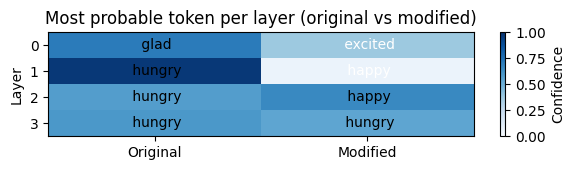

In [2]:
from utils import *

# prompt = "The boy felt so"
# prompt = "The boy cried so"
prompt = "I like to eat toast for breakfast. I\'m so"
# prompt = "I\'m so"
mc_dict = logit_lens(m, mc, prompt, tok, device=DEVICE, use_mc=True)
normal_dict = logit_lens(m, mc, prompt, tok, device=DEVICE, use_mc=False)

import matplotlib.pyplot as plt
import numpy as np

def plot_logit_lens(dict_a, dict_b, cmap="Blues",
                            colnames=("Original", "Modified")):
    layers = sorted(dict_a.keys())
    tokens_a, confs_a = [], []
    tokens_b, confs_b = [], []

    # Extract top-1 token and confidence from each dictionary
    for layer in layers:
        tokdict_a = dict_a[layer]
        tokdict_b = dict_b[layer]

        token_a = max(tokdict_a, key=tokdict_a.get)
        token_b = max(tokdict_b, key=tokdict_b.get)

        conf_a = tokdict_a[token_a]
        conf_b = tokdict_b[token_b]

        tokens_a.append(token_a)
        confs_a.append(conf_a)

        tokens_b.append(token_b)
        confs_b.append(conf_b)

    # Stack into a (num_layers, 2) matrix
    confs = np.stack([confs_a, confs_b], axis=1)

    fig, ax = plt.subplots(figsize=(6, len(layers) * 0.45))

    im = ax.imshow(confs, cmap=cmap, aspect="auto", vmin=0.0, vmax=1.0)

    # Annotate each cell with token text
    for i, layer in enumerate(layers):
        for j, conf in enumerate(confs[i]):
            token = tokens_a[i] if j == 0 else tokens_b[i]
            text_color = "white" if conf < 0.5 else "black"
            ax.text(
                j, i, token,
                ha="center", va="center",
                color=text_color,
                fontsize=10,
            )

    # Axis formatting
    ax.set_xticks([0, 1])
    ax.set_xticklabels(colnames)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layers)
    ax.set_ylabel("Layer")
    ax.set_title("Most probable token per layer (original vs modified)")

    # Colorbar (still from 0 → 1)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Confidence")
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])

    plt.tight_layout()
    plt.savefig("../images/logit_lens.png", dpi=300, format="png")
    plt.show()


plot_logit_lens(normal_dict, mc_dict)


Now visualize which features are most active in different layers

In [4]:
text = [
    "I like eating. I'm so"
]

# If I change to ex
logits = which_most_act(text, tok, mc, tok=-1, device=DEVICE)

--- Layer 0 ---
Feat #1: 9317
Feat #2: 6832
Feat #3: 2439
Feat #4: 9076
Feat #5: 2946
--- Layer 1 ---
Feat #1: 6945
Feat #2: 9510
Feat #3: 7830
Feat #4: 3744
Feat #5: 4208
--- Layer 2 ---
Feat #1: 8635
Feat #2: 2494
Feat #3: 12257
Feat #4: 7542
Feat #5: 7159
--- Layer 3 ---
Feat #1: 10912
Feat #2: 1758
Feat #3: 427
Feat #4: 8992
Feat #5: 7094


In [5]:
text = [
    "I like to eat toast for breakfast. I\'m so"
]

# If I change to ex
logits = which_most_act(text, tok, mc, tok=-1, device=DEVICE)

--- Layer 0 ---
Feat #1: 9317
Feat #2: 6832
Feat #3: 2439
Feat #4: 9076
Feat #5: 2946
--- Layer 1 ---
Feat #1: 6945
Feat #2: 9510
Feat #3: 7830
Feat #4: 3744
Feat #5: 4208
--- Layer 2 ---
Feat #1: 2494
Feat #2: 8635
Feat #3: 7542
Feat #4: 12257
Feat #5: 7159
--- Layer 3 ---
Feat #1: 1758
Feat #2: 10912
Feat #3: 427
Feat #4: 8992
Feat #5: 12167


# Visualize Activations through Dash

Here we visualize features activated by the input prompts in the different layers

In [ ]:
from jupyter_dash import JupyterDash
from dash import dcc, html, Input, Output, Dash
import dash_bootstrap_components as dbc
import numpy as np
import matplotlib
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import torch

# Example tokenized sequences and activations (token-level)
prompts = ["I like toast for breakfast. I'm so", "I'm so"] + test_prompts[10:20]
tokens = [tok.tokenize(prompt) for prompt in prompts]
input_ids = tok(prompts, return_tensors='pt', padding=True)['input_ids']
input_ids = input_ids.to(DEVICE)

outs = mc(input_ids)

# shape: (3 sequences, 7 tokens, 7 features)
activations = outs['feature_activations']
num_features = mc.cfg.num_features

# Color token helper
def color_token(token, act, vmin, vmax):
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    cmap = matplotlib.colormaps['YlOrRd']
    rgba = cmap(norm(act))
    color = f"rgba({int(rgba[0]*255)}, {int(rgba[1]*255)}, {int(rgba[2]*255)}, 0.9)"
    return html.Span(token, title=f"Activation: {act:.4f}", style={
        "backgroundColor": color,
        "padding": "2px",
        "margin": "1px",
        "fontFamily": "monospace"
    })

# Render a sequence with token-level activations
def render_sequence(tokens, activations, eos_token='</s>'):
    if isinstance(activations, torch.Tensor):
        activations = activations.detach().cpu().numpy()

    vmin, vmax = np.min(activations), np.max(activations)
    elements = []

    for token, act in zip(tokens, activations):
        clean_token = token.replace('Ġ', '').strip()  # remove Ġ and extra spaces
        if clean_token == '' or clean_token == eos_token:
            continue  # skip empty or eos tokens
        elements.append(color_token(clean_token, act, vmin, vmax))

    return html.Div(
        elements,
        style={"display": "flex", "flexWrap": "wrap", "marginBottom": "10px"}
    )

# Build app
app = Dash(__name__, external_stylesheets=[dbc.themes.BOOTSTRAP])


app.layout = dbc.Container([
    html.H3("Sparse Feature Activation Visualizer"),

    dbc.Row([
        dbc.Col([
            dbc.Label("Select Transcoder Layer:"),
            dcc.Dropdown(
                id="layer-dropdown",
                options=[{"label": f"Layer {i}", "value": i} for i in range(mc.model_cfg.n_layers)],
                value=0,
                clearable=False
            )
        ]),
        dbc.Col([
            dbc.Label("Select Feature Index:"),
            dcc.Dropdown(
                id="feature-dropdown",
                options=[{'label': f'Feature {i}', 'value': i} for i in range(num_features)],
                value=0,
                clearable=False
            )
        ]) 
    ]),

    html.Hr(),

    html.Div(id="sequence-view")
], fluid=True)

# Callback to update sequences based on feature index
@app.callback(
    Output("sequence-view", "children"),
    [Input("layer-dropdown", "value"),
     Input("feature-dropdown", "value")]
)
def update_feature_view(selected_layer, selected_feature):
    # Extract from activations assuming shape: (B, T, num_features, num_layers)
    
    acts_for_layer = activations[selected_layer][:, :, selected_feature]  # shape: (B, T)

    sequence_rows = []
    for i in range(len(tokens)):
        toks = tokens[i]
        acts = acts_for_layer[i]
        row = html.Div([
            html.Strong(f"Sequence {i}:"), render_sequence(toks, acts)
        ])
        sequence_rows.append(row)

    return sequence_rows


app.run(debug=True, port=8052)

Original:  excited (p=0.4342)
Modified:  hungry (p=0.2742)
Δp[ hungry] = 0.2699
Max DeltaP: [' hungry', ' grateful', ' thirst', ' sorry', ' sad']


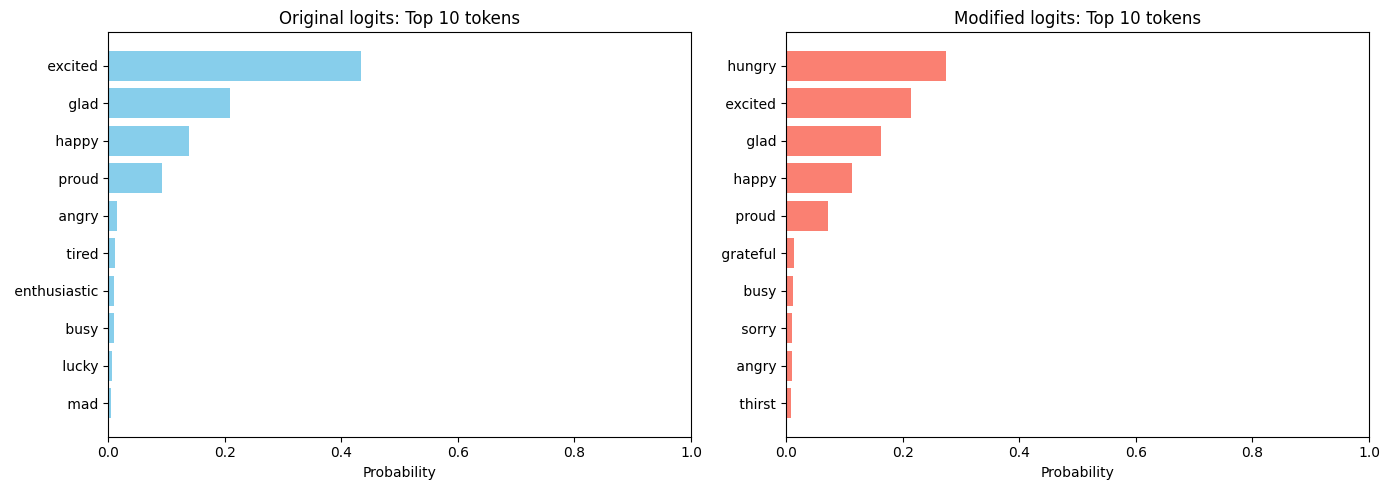

In [5]:
from utils import activate_features_across_layers, plot_top_tokens_comparison

torch.manual_seed(42)

# Text where excited should not be considered
text = "I'm so"

# Forcefully activate feature 6764 in layer 0
original_logits, modified_logits = activate_features_across_layers(text, feature_activation={1: [3498]}, m=m, tok=tok, mc=mc, activation_value=500, device=DEVICE, mitigation_weight=0.5)
plot_top_tokens_comparison(original_logits, modified_logits, tok)


In [6]:
from utils import top_dec_tokens

top_dec_tokens(mc, m, 1, 3498, tok)

[(' ate', 18739),
 (' eat', 6008),
 (' delicious', 17319),
 (' eating', 9123),
 (' tasted', 37907),
 (' y', 340),
 (' taste', 9075),
 (' eaten', 22186),
 (' tasty', 36766),
 (' hungry', 18254)]

In [7]:
from utils import top_embeds_tokens

top_embeds_tokens(mc, 1, 3498, tok)

[(' ate', 18739),
 (' eat', 6008),
 (' delicious', 17319),
 (' eating', 9123),
 (' bowl', 11636),
 (' food', 2739),
 (' y', 340),
 (' hungry', 18254),
 (' fork', 21195),
 (' ju', 7166)]

In [6]:
import numpy as np
import torch
import umap.umap_ as umap
import plotly.graph_objects as go

def plot_tokens_umap_3d(
    token_idx_list,
    embedding_table,   # torch.Tensor (vocab_size, d)
    feature_vec,       # torch.Tensor (d,)
    n_neighbors=15,
    min_dist=0.1,
    metric="cosine",
    random_state=0,
):
    """
    Projects token embeddings + feature vector to 3D with UMAP,
    using normalized vectors.

    - token_idx_list: list of (token, idx)
    - embedding_table: lookup table (vocab_size, d)
    - feature_vec: (d,)
    """

    # -------------------------
    # 1. Extract embeddings
    # -------------------------
    tokens = [t for t, _ in token_idx_list]
    idxs = [i for _, i in token_idx_list]

    emb_matrix = embedding_table[idxs].detach().cpu().numpy()  # (N, d)
    feat = feature_vec.detach().cpu().numpy().reshape(1, -1)   # (1, d)

    X = np.vstack([emb_matrix, feat])      # (N+1, d)

    # -------------------------
    # 2. Normalize (L2 norm)
    # -------------------------
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms == 0] = 1.0
    X_norm = X / norms

    # -------------------------
    # 3. UMAP → 3D
    # -------------------------
    reducer = umap.UMAP(
        n_components=3,
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=random_state,
    )

    coords = reducer.fit_transform(X_norm)  # (N+1, 3)
    token_coords = coords[:-1]
    feature_coord = coords[-1]

    # -------------------------
    # 4. Plotly visualization
    # -------------------------
    fig = go.Figure()

    # Tokens (as labeled points)
    fig.add_trace(go.Scatter3d(
        x=token_coords[:, 0],
        y=token_coords[:, 1],
        z=token_coords[:, 2],
        mode="markers+text",
        text=tokens,
        textposition="top center",
        marker=dict(size=6, opacity=0.9),
        hovertext=[f"{tok}<br>idx={idxs[i]}" for i, tok in enumerate(tokens)],
        hoverinfo="text",
        name="Tokens",
    ))

    # Arrow for the feature vector (from origin)
    fig.add_trace(go.Scatter3d(
        x=[0, feature_coord[0]],
        y=[0, feature_coord[1]],
        z=[0, feature_coord[2]],
        mode="lines",
        line=dict(color="red", width=4),
        name="Feature Vector",
    ))

    # Arrowhead (cone)
    fig.add_trace(go.Cone(
        x=[feature_coord[0]],
        y=[feature_coord[1]],
        z=[feature_coord[2]],
        u=[feature_coord[0]],
        v=[feature_coord[1]],
        w=[feature_coord[2]],
        sizemode="absolute",
        sizeref=0.2,
        anchor="tail",
        showscale=False,
        name="Feature Tip",
        colorscale=[[0, 'rgb(0,0,255)']]
    ))

    fig.update_layout(
        title="3D UMAP Projection (normalized embeddings)",
        width=900,
        height=700,
        scene=dict(
            xaxis_title="UMAP-1",
            yaxis_title="UMAP-2",
            zaxis_title="UMAP-3",
        ),
    )
    fig.show()


layer = 1
num_feat = 3498
plot_tokens_umap_3d(
    token_idx_list=top_embeds_tokens(mc, layer, num_feat, tok),
    embedding_table=m.backbone.embeddings.weight.data,
    feature_vec=mc.encoders[layer].weight.data[num_feat]
)


/storage_1/lruggeri/miniconda3/envs/MambaInterp/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.

/storage_1/lruggeri/miniconda3/envs/MambaInterp/lib/python3.10/site-packages/umap/umap_.py:2462: UserWarning:

n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1



# GENERATION WITH MC

In [6]:
from utils import generate_when_activating

prompt = "Once upon a time"
generate_when_activating(
    prompt,
    feature_activation={1: [3498]},
    m=m,
    tok=tok,
    mc=mc,
    device=DEVICE,
    max_tokens=100,
    activation_value=200,
    mitigation_weight=0.4
)

100%|██████████| 100/100 [00:00<00:00, 193.03it/s]


('Once upon a time, there were two best friends who lived in a town. One day, they went to the town together and wanted to record the beautiful prints on the wall. The ordered one was very colorful.\n\nWhen they arrived at the town, the first friend shouted "Let\'s take that colorful print!" and everyone cheered. The first friend put a big yellow print around the town and the people sent it.\n\nThe friends went back home feeling happy. They had painted the entire town and it',
 'Once upon a time, there was a big tree with lots of yummy prunes. A tree was so tall and so juicy and sweet. \n\nOne leaf was so big that everyone had to cut it. They wanted the prune! \n\nBut then a rude boy came. He kicked the prunes and threw them around. He was being very bad and the children tried to hurt him. \n\nEveryone was scared and ran away quickly. No one helped the rude boy. He was very sad and')

# FORM INTERPRETABILITY CIRCUITS

In [9]:
from circuit_tracing import *
from utils import most_act_diff

input_ids = tok("I like to eat toast for breakfast. I'm so", return_tensors="pt")['input_ids'].to(DEVICE)
text1 = ["I'm so"]
text2 = ["I like to eat toast for breakfast. I'm so"]

most_act_diff(text1, text2, tok, mc, DEVICE) # {1: [3498, 12063, 344]}

_ = m(input_ids)

layer = 1 # because feature is active in layer 1
num_feat = 3498

# Extract feature vector from the first feature (1, 3498)
feature_vector = FeatureVector(
    component_path=[Component(layer=layer, component_type=ComponentType.BLOCK, token=-1, feature_idx=num_feat)],
    vector=mc.encoders[layer].weight.data[num_feat],
    layer=layer,
    sublayer="resid_pre",
    token=-1
)

print([tok.decode(token) for token in input_ids[0]])

paths = greedy_get_top_paths(mc, m.cache, feature_vector)

print_all_paths(paths)

['I', ' like', ' to', ' eat', ' toast', ' for', ' breakfast', '.', ' I', "'m", ' so']
--- Paths of size 2 ---
Path [0][0]: block1@-1->mixer0[920]@3: 0.22
Path [0][1]: block1@-1->embed0@-1: 0.063
Path [0][2]: block1@-1->block0mc[4401]@-1: 0.056
Path [0][3]: block1@-1->block0mc[11443]@-1: 0.053
Path [0][4]: block1@-1->block0mc[12202]@-1: 0.051
--- Paths of size 3 ---
Path [1][0]: block1@-1->mixer0[920]@3: 0.22->embed0@3: -1.5


# MAMBA 130M INTERPRETABILITY

In [1]:
from mambacoder import MambaCoder
from config import TranscoderConfig
from transformers import AutoTokenizer
from datasets import load_dataset
from mamba_py.mambapy.mamba import MambaForLM, MambaConfig
import torch
import torch.nn as nn
from torch import einsum

torch.manual_seed(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Load tinystories dataset
dataset = load_dataset(
    'monology/pile-uncopyrighted',
    data_files='train/00.jsonl.zst',
    split='train[:5%]'
)

# Extract some text prompts
num_test_prompts = 50
test_prompts = dataset[:num_test_prompts]['text']

# Load transcoder config file
t_cfg = TranscoderConfig(
    weight_path="state-spaces/mamba-130m-hf",
    save_path="../models/MambaCoders/mambacoder_130m_pile.pt"
)

# Define Mamba parameters
d_model = 768
n_layers = 24
num_tokens = 50280

m_cfg = MambaConfig(
    d_model,
    n_layers,
    num_tokens
)

# Initialize model, mambacoder and tokenizer
mc = MambaCoder.load_model(
    t_cfg,
    m_cfg
).to(DEVICE)
m = MambaForLM.from_pretrained(
    "state-spaces/mamba-130m-hf"
).to(DEVICE)
tok = AutoTokenizer.from_pretrained("state-spaces/mamba-130m-hf")


/storage_1/lruggeri/miniconda3/envs/MambaInterp/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


So let's see whether for Mamba MJ plays basketball...

In [11]:
from utils import generate
prompt = "Michael Jordan plays the sport of"
input_ids = tok(prompt, return_tensors="pt")['input_ids'].to(DEVICE)

tok.decode(generate(m, max_new_tokens=50, input_ids=input_ids).squeeze())

'Michael Jordan plays the sport of basketball.\n\nMost immortalized is Martin Brodeur, who used to be a passion-hitting United States Hockey League goaltender, but took protective measures to spend more than half of his playing time and alterations nine times a year in'

Apparently yes, so let's see where this concept is formed inside Mamba.

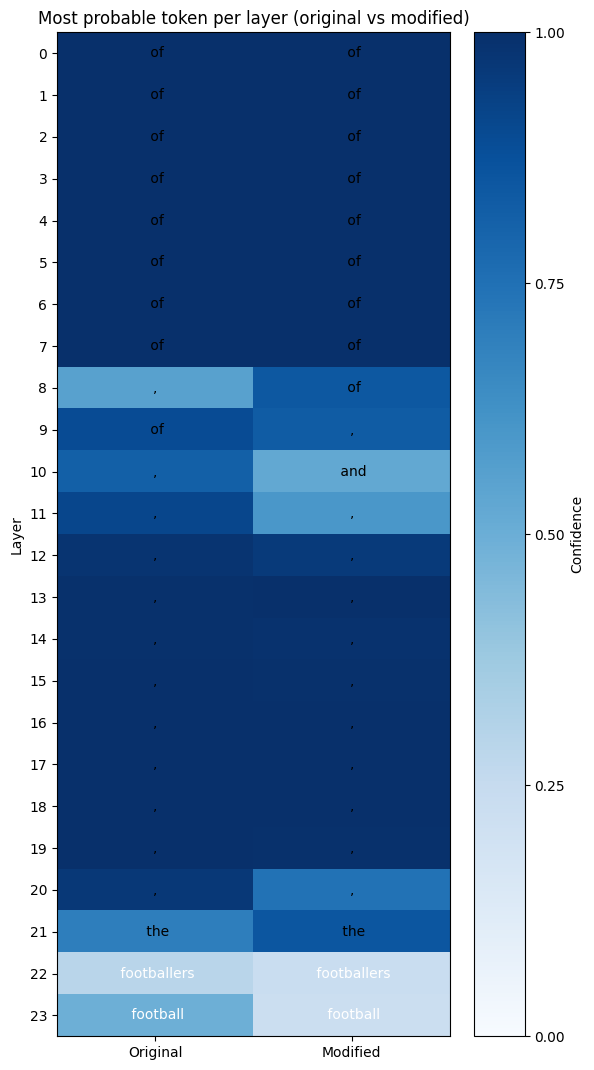

In [4]:
from utils import logit_lens

prompt = "Lionel Messi plays the sport of"

normal_dict = logit_lens(m, mc, prompt, tok, DEVICE, use_mc=False)
mc_dict = logit_lens(m, mc, prompt, tok, DEVICE, use_mc=True)

import matplotlib.pyplot as plt
import numpy as np

def plot_logit_lens(dict_a, dict_b, cmap="Blues",
                            colnames=("Original", "Modified")):
    layers = sorted(dict_a.keys())
    tokens_a, confs_a = [], []
    tokens_b, confs_b = [], []

    # Extract top-1 token and confidence from each dictionary
    for layer in layers:
        tokdict_a = dict_a[layer]
        tokdict_b = dict_b[layer]

        token_a = max(tokdict_a, key=tokdict_a.get)
        token_b = max(tokdict_b, key=tokdict_b.get)

        conf_a = tokdict_a[token_a]
        conf_b = tokdict_b[token_b]

        tokens_a.append(token_a)
        confs_a.append(conf_a)

        tokens_b.append(token_b)
        confs_b.append(conf_b)

    # Stack into a (num_layers, 2) matrix
    confs = np.stack([confs_a, confs_b], axis=1)

    fig, ax = plt.subplots(figsize=(6, len(layers) * 0.45))

    im = ax.imshow(confs, cmap=cmap, aspect="auto", vmin=0.0, vmax=1.0)

    # Annotate each cell with token text
    for i, layer in enumerate(layers):
        for j, conf in enumerate(confs[i]):
            token = tokens_a[i] if j == 0 else tokens_b[i]
            text_color = "white" if conf < 0.5 else "black"
            ax.text(
                j, i, token,
                ha="center", va="center",
                color=text_color,
                fontsize=10,
            )

    # Axis formatting
    ax.set_xticks([0, 1])
    ax.set_xticklabels(colnames)
    ax.set_yticks(range(len(layers)))
    ax.set_yticklabels(layers)
    ax.set_ylabel("Layer")
    ax.set_title("Most probable token per layer (original vs modified)")

    # Colorbar (still from 0 → 1)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Confidence")
    cbar.set_ticks([0.0, 0.25, 0.5, 0.75, 1.0])

    plt.tight_layout()
    plt.savefig("../images/Mamba-SSM-Messi.png", dpi=300)
    plt.show()


plot_logit_lens(normal_dict, mc_dict)

In [4]:
from utils import most_act_diff
prompt1 = [
    "Michael Jordan plays the sport of"
]
prompt2 = [
    "Lionel Messi plays the sport of"
]

most_act_diff(prompt1, prompt2, tok, mc, DEVICE)

{0: {1: {'P1': -0.0, 'P2': -0.0},
  0: {'P1': -0.0, 'P2': -0.0},
  2: {'P1': -0.0, 'P2': -0.0},
  4: {'P1': -0.0, 'P2': -0.0},
  3: {'P1': -0.0, 'P2': -0.0}},
 1: {3925: {'P1': 3.2751846313476562, 'P2': 3.8262557983398438},
  2148: {'P1': 0.0, 'P2': 0.541068434715271},
  3007: {'P1': 0.8084601163864136, 'P2': 0.9798136949539185},
  11785: {'P1': 4.029220104217529, 'P2': 4.161075115203857},
  1065: {'P1': 5.138598918914795, 'P2': 5.269303798675537}},
 2: {10226: {'P1': 0.0, 'P2': 1.0163496732711792},
  3429: {'P1': 0.0, 'P2': 0.9506961107254028},
  7916: {'P1': 4.271836280822754, 'P2': 4.713462829589844},
  5842: {'P1': 1.1778978109359741, 'P2': 1.511275053024292},
  6364: {'P1': 0.990703821182251, 'P2': 1.321401596069336}},
 3: {5614: {'P1': 0.0, 'P2': 1.024998426437378},
  9529: {'P1': 0.0, 'P2': 0.9570127725601196},
  2765: {'P1': 4.438565254211426, 'P2': 4.778631210327148},
  998: {'P1': 4.424428462982178, 'P2': 4.690759181976318},
  3237: {'P1': 7.028748512268066, 'P2': 7.293587207

In [6]:
from utils import top_embeds_tokens

top_embeds_tokens(mc, 23, 4588, tok)

[('amss', 8809),
 (' Syrac', 46578),
 ('enment', 32034),
 ('bersome', 40494),
 ('�', 26601),
 ('arcelona', 23056),
 ('ottenham', 48498),
 ('ancouver', 20719),
 ('�', 175),
 ('estinal', 11278)]

In [7]:
from utils import top_dec_tokens

top_dec_tokens(mc, m, 23, 4588, tok)

[('"});', 43061),
 ('amss', 8809),
 (' loan', 10119),
 ('ottenham', 48498),
 ('loan', 37810),
 ('senal', 23685),
 (' striker', 42857),
 ('iviral', 26818),
 ('"}**).', 39310),
 ('enment', 32034)]

Original:  basketball (p=0.5655)
Modified:  football (p=0.3183)
Δp[ football] = 0.2670
Max DeltaP: [' football', ' sports', ' sport', ' soccer', ' racing']


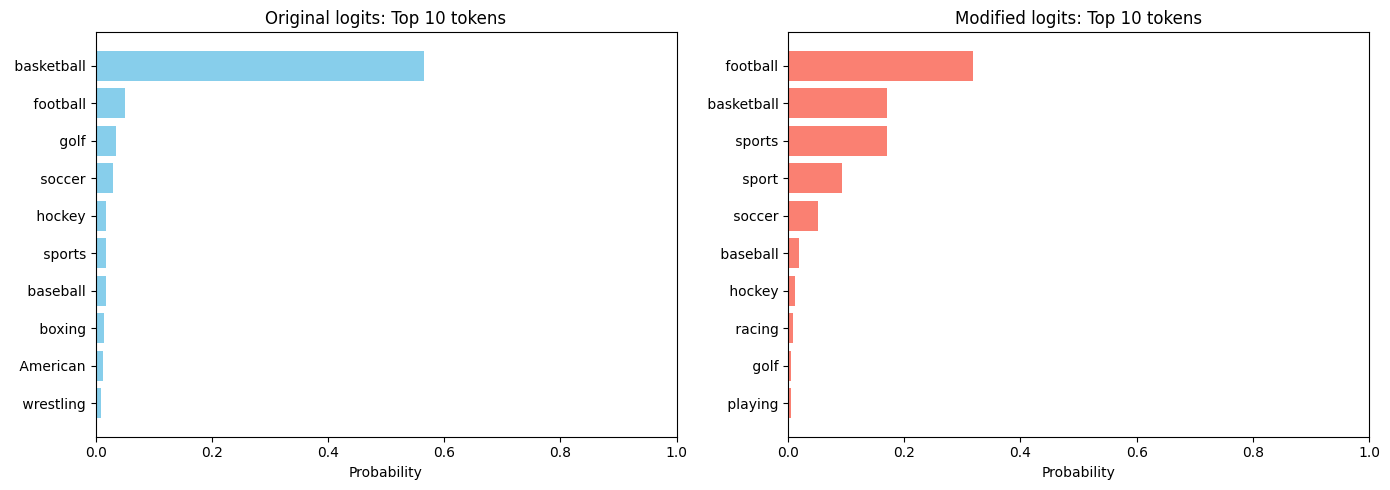

In [8]:
from utils import activate_features_across_layers, plot_top_tokens_comparison

torch.manual_seed(42)

# Text where excited should not be considered
text = "Michael Jordan plays the sport of"

# Forcefully activate feature 6764 in layer 0
original_logits, modified_logits = activate_features_across_layers(text, feature_activation={23: [4588]}, m=m, tok=tok, mc=mc, activation_value=100, device=DEVICE, mitigation_weight=0.5)
plot_top_tokens_comparison(original_logits, modified_logits, tok)


In [14]:
from circuit_tracing import greedy_get_top_paths, print_all_paths, get_top_contribs, FeatureVector, Component, ComponentType
from utils import most_act_diff
from typing import Dict
import copy
import torch.nn.functional as F
input_ids = tok("<|endoftext|> Lionel Messi plays the sport of", return_tensors="pt")['input_ids'].to(DEVICE)
_ = mc(input_ids)

layer = 23 # because feature is active in layer 1
num_feat = 4588

# Extract feature vector from the first feature (1, 3498)
feature_vector = FeatureVector(
    component_path=[Component(layer=layer, component_type=ComponentType.BLOCK, token=-1)],
    vector=mc.encoders[layer].weight.data[num_feat],
    layer=layer,
    sublayer="resid_pre",
    token=-1
)

print([tok.decode(token) for token in input_ids[0]])

@torch.no_grad()
def greedy_get_top_paths_normalized(
    transcoder,
    cache,
    feature_vector,
    num_iters=2,
    num_branches=5,
    novelty_weight=0.5,   # bigger weight => more exploration
):
    feature_vector.vector = feature_vector.vector.to(transcoder.cfg.device)

    all_paths = []
    root = copy.deepcopy(feature_vector)
    cur_paths = [[root]]
    # counts per feature id
    seen = {}  # key: (layer, idx, sublayer) -> count

    for _ in range(num_iters):
        new_paths = []
        # gather all raw contribs for normalization per parent
        parent_to_cands = []
        for path in cur_paths:
            last_feat = path[-1]
            if last_feat.layer == 0 and last_feat.sublayer == "resid_pre":
                continue
            top_contribs = get_top_contribs(transcoder, cache, last_feat, k=num_branches*2)
            parent_to_cands.append((path, top_contribs))

        # process each parent's candidates (normalize then penalty)
        for path, top_contribs in parent_to_cands:
            raw = torch.tensor([float(c.contrib) for c in top_contribs])
            if raw.numel() == 0:
                continue
            mean = raw.mean()
            std = raw.std(unbiased=False).clamp(min=1e-6)
            normalized = (raw - mean) / std  # z-score
            for c, z in zip(top_contribs, normalized):
                key = (c.layer, getattr(c, "idx", None), c.sublayer)
                count = seen.get(key, 0)
                adjusted = float(z) - novelty_weight * (count)
                # store adjusted into a separate field to avoid overwriting original
                c._adjusted = adjusted
                new_paths.append(path + [c])
                # do NOT bump seen here — bump when the candidate is actually selected

        # select top branches while updating seen
        if len(new_paths) == 0:
            break
        scores = torch.tensor([p[-1]._adjusted for p in new_paths])
        _, top_idx = torch.topk(scores, k=min(num_branches, len(new_paths)))
        selected = [new_paths[i] for i in top_idx]

        # update seen counts for selected features
        for p in selected:
            c = p[-1]
            key = (c.layer, getattr(c, "idx", None), c.sublayer)
            seen[key] = seen.get(key, 0) + 1

        cur_paths = selected
        all_paths.append(cur_paths)

    return all_paths

paths = greedy_get_top_paths_normalized(mc, mc.base_model.cache, feature_vector, num_iters=8, num_branches=8)

print_all_paths(paths)

['<|endoftext|>', ' Lion', 'el', ' Mess', 'i', ' plays', ' the', ' sport', ' of']


--- Paths of size 2 ---
Path [0][0]: block23@-1->mixer17[1147]@0: 1.2
Path [0][1]: block23@-1->mixer22[64]@7: 1.0
Path [0][2]: block23@-1->block20mc[4923]@-1: 0.82
Path [0][3]: block23@-1->mixer21[311]@6: 0.76
Path [0][4]: block23@-1->block19mc[3778]@-1: 0.71
Path [0][5]: block23@-1->block20mc[10088]@-1: 0.7
Path [0][6]: block23@-1->block22mc[8744]@-1: 0.66
Path [0][7]: block23@-1->mixer22[64]@4: 0.64
--- Paths of size 3 ---
Path [1][0]: block23@-1->mixer17[1147]@0: 1.2->block13mc[5651]@0: 4.5e+01
Path [1][1]: block23@-1->block20mc[10088]@-1: 0.7->mixer19[1512]@5: 0.21
Path [1][2]: block23@-1->mixer22[64]@7: 1.0->block18mc[10338]@7: 0.061
Path [1][3]: block23@-1->block20mc[4923]@-1: 0.82->block19mc[12083]@-1: 0.57
Path [1][4]: block23@-1->mixer22[64]@4: 0.64->block18mc[10338]@4: 0.05
Path [1][5]: block23@-1->mixer21[311]@6: 0.76->mixer18[542]@5: 0.13
Path [1][6]: block23@-1->mixer21[311]@6: 0.76->mixer18[542]@1: 0.13
Path [1][7]: block23@-1->mixer22[64]@4: 0.64->mixer20[258]@2: 0.047
-

In [11]:
from utils import which_most_act

prompt = ["<xml version"]

which_most_act(prompt, tok, mc, DEVICE, tok=-2)

--- Layer 0 ---
Feat #1: 7346
Feat #2: 11597
Feat #3: 7945
Feat #4: 7392
Feat #5: 181
--- Layer 1 ---
Feat #1: 10428
Feat #2: 3866
Feat #3: 4465
Feat #4: 8154
Feat #5: 349
--- Layer 2 ---
Feat #1: 2179
Feat #2: 142
Feat #3: 10573
Feat #4: 4833
Feat #5: 4225
--- Layer 3 ---
Feat #1: 3547
Feat #2: 5462
Feat #3: 7593
Feat #4: 3086
Feat #5: 3017
--- Layer 4 ---
Feat #1: 7511
Feat #2: 88
Feat #3: 2533
Feat #4: 6782
Feat #5: 6936
--- Layer 5 ---
Feat #1: 7185
Feat #2: 6581
Feat #3: 12239
Feat #4: 1649
Feat #5: 11424
--- Layer 6 ---
Feat #1: 6383
Feat #2: 2604
Feat #3: 1638
Feat #4: 9035
Feat #5: 7220
--- Layer 7 ---
Feat #1: 2599
Feat #2: 11064
Feat #3: 1071
Feat #4: 522
Feat #5: 12282
--- Layer 8 ---
Feat #1: 11645
Feat #2: 3252
Feat #3: 10614
Feat #4: 7044
Feat #5: 7450
--- Layer 9 ---
Feat #1: 3343
Feat #2: 6177
Feat #3: 8818
Feat #4: 1379
Feat #5: 9500
--- Layer 10 ---
Feat #1: 11785
Feat #2: 4166
Feat #3: 967
Feat #4: 12241
Feat #5: 3634
--- Layer 11 ---
Feat #1: 5374
Feat #2: 5226
Feat

tensor([[[ 66.0045,  51.3385,  66.3075,  ...,  51.5170,  51.3818,  51.4480],
         [ 54.4273,  44.4082,  56.7238,  ...,  44.7565,  44.4324,  44.5389],
         [-31.4579, -40.6979, -31.8629,  ..., -40.5539, -40.3376, -40.9002]]],
       device='cuda:0')

In [91]:
from utils import most_act_diff

prompt1 = "You must use c++"
prompt2 = "#include 'ttc.h'\n#include <stdio.h>\n#include <stdlib.h>\n#include <string.h>\n\n#if IEEE16bit_DIMAGES\n#include 'init_read.h"

most_act_diff(prompt1, prompt2, tok, mc, DEVICE)

{0: {1820: {'P1': -0.0, 'P2': 18.15227508544922},
  1360: {'P1': -0.0, 'P2': 9.709778785705566},
  8367: {'P1': -0.0, 'P2': 8.915552139282227},
  39: {'P1': -0.0, 'P2': 8.690244674682617},
  1476: {'P1': -0.0, 'P2': 4.491335868835449}},
 1: {5158: {'P1': -0.0, 'P2': 13.095503807067871},
  959: {'P1': -0.0, 'P2': 8.461389541625977},
  4907: {'P1': -0.0, 'P2': 7.570647239685059},
  10356: {'P1': -0.0, 'P2': 7.490081787109375},
  5704: {'P1': -0.0, 'P2': 7.42378044128418}},
 2: {8057: {'P1': -0.0, 'P2': 15.844382286071777},
  1567: {'P1': -0.0, 'P2': 9.711750984191895},
  3399: {'P1': -0.0, 'P2': 6.168859481811523},
  2969: {'P1': -0.0, 'P2': 4.5744476318359375},
  2952: {'P1': -0.0, 'P2': 4.387720584869385}},
 3: {5015: {'P1': 0.0, 'P2': 17.85555648803711},
  10041: {'P1': 0.0, 'P2': 9.431249618530273},
  2244: {'P1': -0.0, 'P2': 8.37317943572998},
  11523: {'P1': -0.0, 'P2': 7.400484085083008},
  6698: {'P1': -0.0, 'P2': 6.5903120040893555}},
 4: {2207: {'P1': -0.0, 'P2': 17.37527275085

In [99]:
from utils import top_embeds_tokens

top_embeds_tokens(mc, 21, 6470, tok)

[('[]$', 27618),
 ('inical', 9641),
 ('amss', 8809),
 ('chemic', 23413),
 ('ernate', 25028),
 ('enment', 32034),
 ('grily', 44634),
 ('izontal', 19650),
 (' teasp', 13236),
 ('ORAND', 38438)]

In [71]:
from utils import top_dec_tokens

top_dec_tokens(mc, m, 22, 4904, tok)

[(' type', 1511),
 ('��', 34918),
 (' ingred', 10275),
 ('othelium', 41259),
 (' TYPE', 39024),
 ('amilies', 27099),
 ('type', 881),
 (' href', 3860),
 (' defer', 36574),
 ('outube', 19834)]

In [90]:
from utils import generate_when_activating

text_prompt = "#include"

generate_when_activating(text_prompt, feature_activation={23: [3134], 22: [4904]}, m=m, tok=tok, mc=mc, device=DEVICE, max_tokens=50, activation_value=10, mitigation_weight=0.3)

100%|██████████| 50/50 [00:00<00:00, 54.01it/s]


('#include "ttc.h"\n#include <stdio.h>\n#include <stdlib.h>\n#include <string.h>\n\n#if IEEE16bit_DIMAGES\n#include "init_read.h',
 '#include "modules/core/types.h"\n\n#include "modules/util/internal/libinternal_table.h"\n\n#include "rest_base_internal_types.h"\n\n#include "uuid/internal')